## 분산투자



금융 시장에서 '유일한 공짜 점심'은 바로 분산투자입니다. 신(God)이 아닌 이상, 매번 최고의 종목을 맞히는 것은 불가능합니다. 예측의 영역이 아닌 대응의 영역에서, 분산투자는 개별 종목의 치명적인 위험을 상쇄하고 포트폴리오의 변동성을 제어하는 가장 강력한 수학적 도구입니다.

투자의 적은 시장이 아니라, 흔들리는 투자자의 마음입니다. 한 종목에 모든 것을 걸면 작은 파도에도 멀미를 느끼지만, 여러 배에 나누어 실으면 거친 파도도 유연하게 넘을 수 있습니다. 분산투자는 수익률뿐만 아니라, 밤에 발 뻗고 잘 수 있는 '심리적 안정값'까지 확보하는 지혜입니다.

In [27]:
pip install -U finance-datareader

In [28]:
import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [29]:
# 데이터 가져오기

samsung = fdr.DataReader("005930", "2018", "2025-12-10")
skhynix = fdr.DataReader("000660", "2018", "2025-12-10")
hyundai = fdr.DataReader("005380", "2018", "2025-12-10")
naver = fdr.DataReader("035420", "2018", "2025-12-10")
kb = fdr.DataReader("105560", "2018", "2025-12-10")

print(samsung.head())
print(skhynix.head())
print(hyundai.head())
print(naver.head())
print(kb.head())

             Open   High    Low  Close  Volume    Change
Date                                                    
2018-01-02  51380  51400  50780  51020  169485  0.001177
2018-01-03  52540  52560  51420  51620  200270  0.011760
2018-01-04  52120  52180  50640  51080  233909 -0.010461
2018-01-05  51300  52120  51200  52120  189623  0.020360
2018-01-08  52400  52520  51500  52020  167673 -0.001919
             Open   High    Low  Close   Volume    Change
Date                                                     
2018-01-02  77300  77300  76200  76600  2014838  0.001307
2018-01-03  78100  78800  77300  77700  3097644  0.014360
2018-01-04  78700  79700  77100  77100  3729328 -0.007722
2018-01-05  78400  79400  78300  79300  3395065  0.028534
2018-01-08  79500  80000  77400  78200  2960495 -0.013871
              Open    High     Low   Close  Volume    Change
Date                                                        
2018-01-02  150500  153000  149000  149500  731763 -0.041667
2018-01-03  

In [30]:
# 결측치 검사, 데이터에 결측치는 없다.
print(pd.isnull(samsung).sum())
print(pd.isnull(skhynix).sum())
print(pd.isnull(hyundai).sum())
print(pd.isnull(naver).sum())
print(pd.isnull(kb).sum())


Open      0
High      0
Low       0
Close     0
Volume    0
Change    0
dtype: int64
Open      0
High      0
Low       0
Close     0
Volume    0
Change    0
dtype: int64
Open      0
High      0
Low       0
Close     0
Volume    0
Change    0
dtype: int64
Open      0
High      0
Low       0
Close     0
Volume    0
Change    0
dtype: int64
Open      0
High      0
Low       0
Close     0
Volume    0
Change    0
dtype: int64


**삼성전자 단일 종목 투자성과**

In [31]:
samsung['Close']

,Close
Date,
2018-01-02,51020
2018-01-03,51620
2018-01-04,51080
2018-01-05,52120
2018-01-08,52020
...,...
2025-12-04,105100
2025-12-05,108400
2025-12-08,109500


In [32]:
# 삼성전자 단일 종목 수익률
samsungDayReturn = (samsung['Close'] / samsung['Close'].shift(1)).fillna(1)
samsungDayReturn

,Close
Date,
2018-01-02,1.000000
2018-01-03,1.011760
2018-01-04,0.989539
2018-01-05,1.020360
2018-01-08,0.998081
...,...
2025-12-04,1.005742
2025-12-05,1.031399
2025-12-08,1.010148


In [33]:
# 삼전 누적수익률
samsungCumulativeReturn = samsungDayReturn.cumprod()
samsungCumulativeReturn

,Close
Date,
2018-01-02,1.000000
2018-01-03,1.011760
2018-01-04,1.001176
2018-01-05,1.021560
2018-01-08,1.019600
...,...
2025-12-04,2.059976
2025-12-05,2.124657
2025-12-08,2.146217


In [11]:
# 누적수익률을 구하는 다른 방법
samsungCumulatieReturn = samsung['Close'] / samsung['Close'].iloc[0]
samsungCumulativeReturn

,Close
Date,
2018-01-02,1.000000
2018-01-03,1.011760
2018-01-04,1.001176
2018-01-05,1.021560
2018-01-08,1.019600
...,...
2025-12-04,2.059976
2025-12-05,2.124657
2025-12-08,2.146217


In [34]:
# cagr
samsungCagr = samsungCumulativeReturn.iloc[-1] ** (252/len(samsung))
# mdd
samsungDd = (samsungCumulativeReturn.cummax() - samsungCumulativeReturn) / samsungCumulativeReturn.cummax() * 100
samsungMdd = samsungDd.max()

print("cagr: ",samsungCagr)
print("mdd: ",samsungMdd)

cagr:  1.1017633043548536
mdd:  45.16483516483517


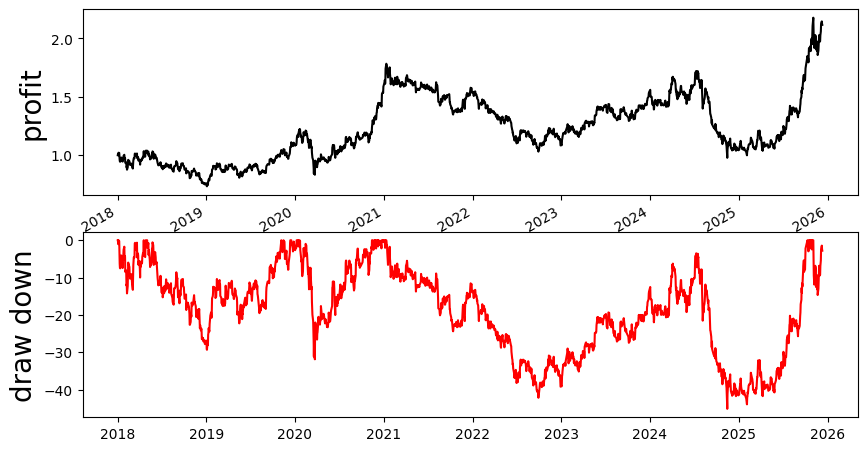

In [35]:
# 시각화
plt.figure(figsize=(10, 6))

# 수익곡선
plt.subplot(2, 1, 1)
samsungCumulativeReturn.plot(color="black")
plt.ylabel("profit", fontsize=20)

# 낙폭곡선
plt.subplot(2, 1, 2)
plt.plot(-samsungDd, color="red")
plt.ylabel("draw down", fontsize=20)
plt.show()

**5개 종목 분산 투자 성과와 누적 수익률 곡선**

In [37]:
#5개 종목 종가를 하나의 데이터프레임으로 합치기
stocks = [samsung, skhynix, hyundai, naver, kb]
data = pd.DataFrame()

for stock in stocks:
    data = pd.concat([data, stock['Close']], axis=1)

data.columns = ["samsung", "skhynix", "hyundai", "naver", "kb"]

data

,samsung,skhynix,hyundai,naver,kb
2018-01-02 00:00:00,51020,76600,149500,177251,63100
2018-01-03 00:00:00,51620,77700,150500,174447,63100
2018-01-04 00:00:00,51080,77100,146500,178853,63000
2018-01-05 00:00:00,52120,79300,149000,181857,64100
2018-01-08 00:00:00,52020,78200,151000,190269,66600
...,...,...,...,...,...
2025-12-04 00:00:00,105100,542000,283500,247000,128800
2025-12-05 00:00:00,108400,544000,315000,249500,130700
2025-12-08 00:00:00,109500,577000,315500,249000,127900
2025-12-09 00:00:00,108400,566000,307000,248000,126000


## 누적수익률 계산

In [38]:
# 개별 자산 일별 수익률
dayReturn = (data / data.shift(1)).fillna(1)
dayReturn

,samsung,skhynix,hyundai,naver,kb
2018-01-02 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000
2018-01-03 00:00:00,1.011760,1.014360,1.006689,0.984181,1.000000
2018-01-04 00:00:00,0.989539,0.992278,0.973422,1.025257,0.998415
2018-01-05 00:00:00,1.020360,1.028534,1.017065,1.016796,1.017460
2018-01-08 00:00:00,0.998081,0.986129,1.013423,1.046256,1.039002
...,...,...,...,...,...
2025-12-04 00:00:00,1.005742,0.981884,1.063790,1.002028,0.977980
2025-12-05 00:00:00,1.031399,1.003690,1.111111,1.010121,1.014752
2025-12-08 00:00:00,1.010148,1.060662,1.001587,0.997996,0.978577
2025-12-09 00:00:00,0.989954,0.980936,0.973059,0.995984,0.985145


In [39]:
# 개별 자산 누적 수익률
cumReturn = data / data.iloc[0]
cumReturn

,samsung,skhynix,hyundai,naver,kb
2018-01-02 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000
2018-01-03 00:00:00,1.011760,1.014360,1.006689,0.984181,1.000000
2018-01-04 00:00:00,1.001176,1.006527,0.979933,1.009038,0.998415
2018-01-05 00:00:00,1.021560,1.035248,0.996656,1.025986,1.015848
2018-01-08 00:00:00,1.019600,1.020888,1.010033,1.073444,1.055468
...,...,...,...,...,...
2025-12-04 00:00:00,2.059976,7.075718,1.896321,1.393504,2.041204
2025-12-05 00:00:00,2.124657,7.101828,2.107023,1.407608,2.071315
2025-12-08 00:00:00,2.146217,7.532637,2.110368,1.404788,2.026941
2025-12-09 00:00:00,2.124657,7.389034,2.053512,1.399146,1.996830


In [40]:
# 포트폴리오 비율 : 동일 가중
portWeight = [1/len(data.columns)] * len(data.columns)
portWeight

[0.2, 0.2, 0.2, 0.2, 0.2]

In [41]:
# 누적 수익률
portCumReturn = (portWeight * cumReturn).sum(axis=1)
portCumReturn

,0
2018-01-02 00:00:00,1.000000
2018-01-03 00:00:00,1.003398
2018-01-04 00:00:00,0.999018
2018-01-05 00:00:00,1.019059
2018-01-08 00:00:00,1.035887
...,...
2025-12-04 00:00:00,2.893345
2025-12-05 00:00:00,2.962486
2025-12-08 00:00:00,3.044190
2025-12-09 00:00:00,2.992636


## 일간 수익률

### 1. 역연산 방법

In [42]:
portDayReturn = (portCumReturn / portCumReturn.shift(1)).fillna(1)
portDayReturn

,0
2018-01-02 00:00:00,1.000000
2018-01-03 00:00:00,1.003398
2018-01-04 00:00:00,0.995635
2018-01-05 00:00:00,1.020061
2018-01-08 00:00:00,1.016512
...,...
2025-12-04 00:00:00,0.996678
2025-12-05 00:00:00,1.023897
2025-12-08 00:00:00,1.027579
2025-12-09 00:00:00,0.983065


**분산투자 포트폴리오와 개별 종목 투자 결과 비교**

In [43]:
# 개별 자산 누적수익률
cumReturn

,samsung,skhynix,hyundai,naver,kb
2018-01-02 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000
2018-01-03 00:00:00,1.011760,1.014360,1.006689,0.984181,1.000000
2018-01-04 00:00:00,1.001176,1.006527,0.979933,1.009038,0.998415
2018-01-05 00:00:00,1.021560,1.035248,0.996656,1.025986,1.015848
2018-01-08 00:00:00,1.019600,1.020888,1.010033,1.073444,1.055468
...,...,...,...,...,...
2025-12-04 00:00:00,2.059976,7.075718,1.896321,1.393504,2.041204
2025-12-05 00:00:00,2.124657,7.101828,2.107023,1.407608,2.071315
2025-12-08 00:00:00,2.146217,7.532637,2.110368,1.404788,2.026941
2025-12-09 00:00:00,2.124657,7.389034,2.053512,1.399146,1.996830


samsung
cagr: 1.1017633043548534
mdd: 45.16483516483517
skhynix
cagr: 1.301046738211924
mdd: 49.494949494949495
hyundai
cagr: 1.0953565128443818
mdd: 59.8170731707317
naver
cagr: 1.0424428815457414
mdd: 65.85903083700441
kb
cagr: 1.0917951688065228
mdd: 62.026239067055386
portfolio
cagr: 1.154088067696092
mdd: 40.54507334120731


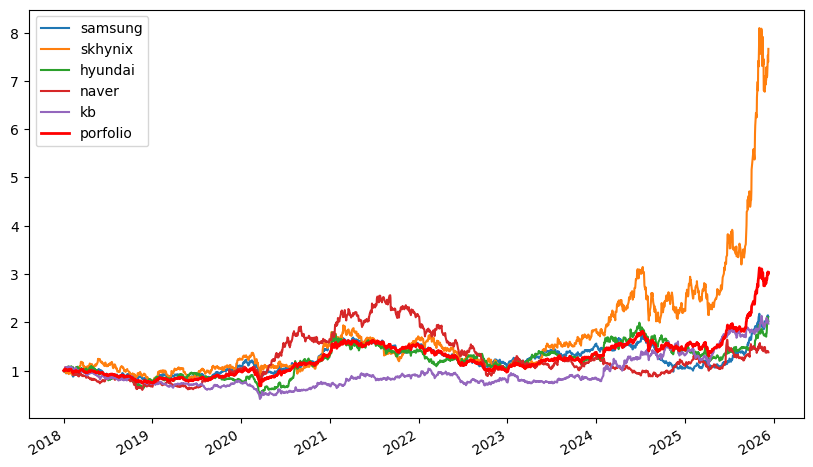

In [44]:
plt.figure(figsize=(10, 6))

for stock in cumReturn.columns:
    # 그래프
    cumReturn[stock].plot(label=stock)
    # cagr
    cagr = cumReturn[stock].iloc[-1] ** (252/len(cumReturn[stock]))
    # mdd
    dd = (cumReturn[stock].cummax() - cumReturn[stock]) / cumReturn[stock].cummax() * 100
    mdd= dd.max()

    print(stock)
    print(f"cagr: {cagr}\nmdd: {mdd}")
    print("=======")


# cagr
cagr = portCumReturn.iloc[-1] ** (252/len(portCumReturn))
# mdd
dd = (portCumReturn.cummax() - portCumReturn) / portCumReturn.cummax() * 100
mdd= dd.max()

print("portfolio")
print(f"cagr: {cagr}\nmdd: {mdd}")
print("=======")

portCumReturn.plot(label = "porfolio", color="red", linewidth=2)
plt.legend()
plt.show()

### 2. 비율 계산 방법

In [25]:
# 자산별 비중이 반영된 자산 흐름
weightedCumReturn = portWeight * cumReturn
weightedCumReturn

,samsung,skhynix,hyundai,naver,kb
2018-01-02 00:00:00,0.200000,0.200000,0.200000,0.200000,0.200000
2018-01-03 00:00:00,0.202352,0.202872,0.201338,0.196836,0.200000
2018-01-04 00:00:00,0.200235,0.201305,0.195987,0.201808,0.199683
2018-01-05 00:00:00,0.204312,0.207050,0.199331,0.205197,0.203170
2018-01-08 00:00:00,0.203920,0.204178,0.202007,0.214689,0.211094
...,...,...,...,...,...
2025-12-04 00:00:00,0.411995,1.415144,0.379264,0.278701,0.408241
2025-12-05 00:00:00,0.424931,1.420366,0.421405,0.281522,0.414263
2025-12-08 00:00:00,0.429243,1.506527,0.422074,0.280958,0.405388
2025-12-09 00:00:00,0.424931,1.477807,0.410702,0.279829,0.399366


In [45]:
weightedCumReturn.sum(axis=1)

,0
2018-01-02 00:00:00,1.000000
2018-01-03 00:00:00,1.003398
2018-01-04 00:00:00,0.999018
2018-01-05 00:00:00,1.019059
2018-01-08 00:00:00,1.035887
...,...
2025-12-04 00:00:00,2.893345
2025-12-05 00:00:00,2.962486
2025-12-08 00:00:00,3.044190
2025-12-09 00:00:00,2.992636


In [47]:
# 자산 비율 => 자산 흐름 정규화
assetRatio = weightedCumReturn.divide(weightedCumReturn.sum(axis=1), axis=0)
assetRatio

,samsung,skhynix,hyundai,naver,kb
2018-01-02 00:00:00,0.200000,0.200000,0.200000,0.200000,0.200000
2018-01-03 00:00:00,0.201667,0.202185,0.200656,0.196170,0.199323
2018-01-04 00:00:00,0.200432,0.201503,0.196179,0.202006,0.199879
2018-01-05 00:00:00,0.200491,0.203177,0.195603,0.201359,0.199370
2018-01-08 00:00:00,0.196856,0.197104,0.195009,0.207251,0.203781
...,...,...,...,...,...
2025-12-04 00:00:00,0.142394,0.489103,0.131082,0.096325,0.141097
2025-12-05 00:00:00,0.143437,0.479450,0.142247,0.095029,0.139836
2025-12-08 00:00:00,0.141004,0.494886,0.138649,0.092293,0.133168
2025-12-09 00:00:00,0.141992,0.493814,0.137238,0.093506,0.133450


In [ ]:
# 포트폴리오 개별자산 순 수익률
assetRatio * dayReturn.shift(-1)

,samsung,skhynix,hyundai,naver,kb
2018-01-02 00:00:00,0.202352,0.202872,0.201338,0.196836,0.200000
2018-01-03 00:00:00,0.199557,0.200624,0.195323,0.201124,0.199007
2018-01-04 00:00:00,0.204513,0.207253,0.199527,0.205399,0.203369
2018-01-05 00:00:00,0.200106,0.200359,0.198229,0.210673,0.207145
2018-01-08 00:00:00,0.190725,0.193827,0.196946,0.205943,0.205616
...,...,...,...,...,...
2025-12-04 00:00:00,0.146865,0.490908,0.145646,0.097300,0.143178
2025-12-05 00:00:00,0.144893,0.508535,0.142473,0.094838,0.136841
2025-12-08 00:00:00,0.139588,0.485452,0.134913,0.091922,0.131190
2025-12-09 00:00:00,0.141468,0.512136,0.135226,0.092186,0.131861


In [48]:
# 포트폴리오 일간 수익률
portDayReturn2 = (assetRatio * dayReturn.shift(-1)).sum(axis=1).shift(1).fillna(1)
portDayReturn2

,0
2018-01-02 00:00:00,1.000000
2018-01-03 00:00:00,1.003398
2018-01-04 00:00:00,0.995635
2018-01-05 00:00:00,1.020061
2018-01-08 00:00:00,1.016512
...,...
2025-12-04 00:00:00,0.996678
2025-12-05 00:00:00,1.023897
2025-12-08 00:00:00,1.027579
2025-12-09 00:00:00,0.983065


In [49]:
# 포트폴리오 누적 수익률
portCumReturn2 = portDayReturn.cumprod()
portCumReturn2

,0
2018-01-02 00:00:00,1.000000
2018-01-03 00:00:00,1.003398
2018-01-04 00:00:00,0.999018
2018-01-05 00:00:00,1.019059
2018-01-08 00:00:00,1.035887
...,...
2025-12-04 00:00:00,2.893345
2025-12-05 00:00:00,2.962486
2025-12-08 00:00:00,3.044190
2025-12-09 00:00:00,2.992636


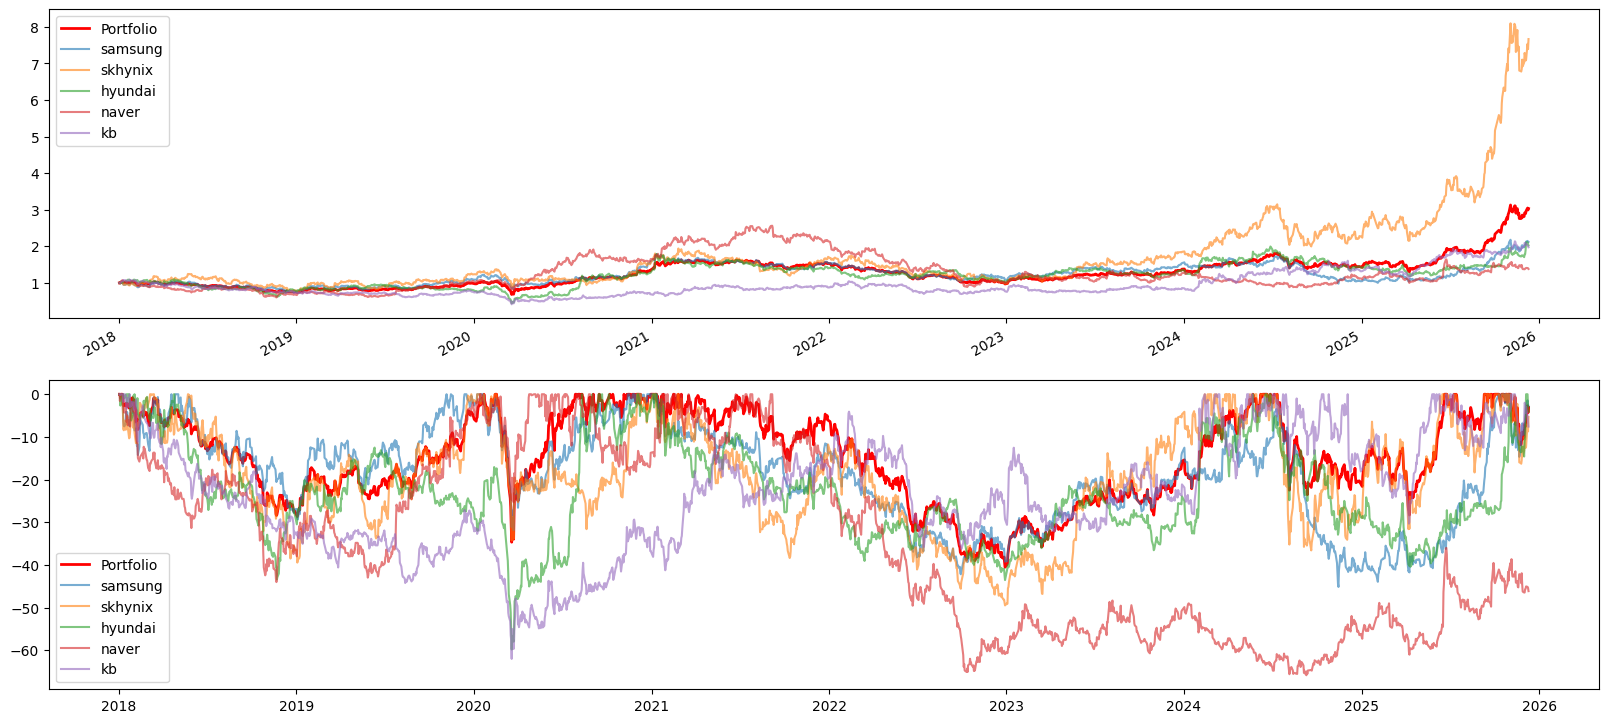

In [50]:
plt.figure(figsize=(20, 10))

# 1. 수익곡선 (Cumulative Return)
plt.subplot(2, 1, 1)
# 포트폴리오 수익률 (잘 보이게 빨간색, 굵게)
portCumReturn.plot(color="red", label="Portfolio", linewidth=2)

# 개별 종목 수익률 반복 출력
for stock in cumReturn.columns:
    cumReturn[stock].plot(label=stock, alpha=0.6)

plt.ylabel="profit"
plt.legend()

# 2. 낙폭곡선 (Drawdown)
plt.subplot(2, 1, 2)
# 포트폴리오 낙폭
plt.plot(-dd, color="red", label="Portfolio", linewidth=2)

# 개별 종목 낙폭 반복 출력
for stock in cumReturn.columns:
    # 개별 종목 낙폭 계산
    stock_dd = (cumReturn[stock].cummax() - cumReturn[stock]) / cumReturn[stock].cummax() * 100
    plt.plot(-stock_dd, label=stock, alpha=0.6)

plt.ylabel="draw down"
plt.legend()
plt.show()